In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

from cmdstanpy import CmdStanModel

In [2]:
model = CmdStanModel(
    stan_file="models/regression_model.stan"
)

In [51]:
# change N20 <=> N200 to run fit on other data
data = pd.read_csv("data/generated_data_N200.csv", delimiter=",", header=0)

data_dict = {
    "N": len(data),
    "x": data.X.values,
    "y": data.Y.values,
}

In [52]:
print("##### N=20:")
print(pd.read_csv("summary_N20.csv",index_col=0)[["Mean","StdDev","ESS_bulk","ESS_tail","R_hat"]].iloc[:5].to_markdown())
print("##### N=200:")
print(pd.read_csv("summary_N200.csv",index_col=0)[["Mean","StdDev","ESS_bulk","ESS_tail","R_hat"]].iloc[:5].to_markdown())


##### N=20:
|        |      Mean |   StdDev |   ESS_bulk |   ESS_tail |   R_hat |
|:-------|----------:|---------:|-----------:|-----------:|--------:|
| lp__   | -53.3982  |  1.30685 |    8673.29 |    9938.59 | 1.00029 |
| alpha  | -13.2449  |  1.81079 |   10924    |   11002.2  | 1.00036 |
| beta   |   8.62474 |  1.75149 |   10893.6  |   11823.2  | 1.00032 |
| sigma2 |  44.4745  | 15.702   |   12018.3  |   11416.1  | 1.00016 |
| sigma  |   6.5773  |  1.10168 |   12018.3  |   11416.1  | 1.00016 |
##### N=200:
|        |       Mean |   StdDev |   ESS_bulk |   ESS_tail |   R_hat |
|:-------|-----------:|---------:|-----------:|-----------:|--------:|
| lp__   | -478.086   | 1.24632  |    9520.99 |    12654.9 | 1.00035 |
| alpha  |  -10.762   | 0.55942  |   13189.2  |    12415   | 1.00014 |
| beta   |    9.24301 | 0.558619 |   13303.9  |    13268   | 1.00025 |
| sigma2 |   41.6207  | 4.25367  |   13619.2  |    13001.3 | 1.00011 |
| sigma  |    6.44307 | 0.327929 |   13619.2  |    13001.3 

In [53]:
NUM_CHAINS = 4
SAMPLING_ITERS = 5_000

fit = model.sample(
    data=data_dict, 
    chains=NUM_CHAINS, 
    iter_warmup=500, 
    iter_sampling=SAMPLING_ITERS,
)

01:32:41 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

01:32:44 - cmdstanpy - INFO - CmdStan done processing.


In [54]:
summary=fit.summary()
summary.to_csv(f"summary_N{data_dict['N']}.csv",index=True)
summary

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-478.04200,0.012467,1.218600,1.004490,-480.44700,-477.72300,-476.71500,9907.47,13028.1,1089.21,1.000050
alpha,-10.76370,0.004902,0.553259,0.548271,-11.67050,-10.76490,-9.85032,12755.00,13364.5,1402.26,1.000280
beta,9.24290,0.004830,0.549206,0.542274,8.33671,9.24936,10.14290,12957.00,14062.0,1424.47,1.000090
sigma2,41.59200,0.035664,4.199000,4.138530,35.14500,41.33090,48.94250,14018.30,12400.0,1541.15,1.000010
sigma,6.44106,0.002744,0.323731,0.322137,5.92832,6.42891,6.99589,14018.30,12400.0,1541.15,1.000010
...,...,...,...,...,...,...,...,...,...,...,...
y_pp[196],-2.53354,0.045922,6.489470,6.466750,-13.04700,-2.56032,8.10781,19975.70,19275.3,2196.09,0.999947
y_pp[197],-8.61991,0.047003,6.555440,6.511500,-19.44940,-8.61614,2.14570,19467.60,19598.5,2140.23,1.000010
y_pp[198],-6.05690,0.045916,6.453280,6.434090,-16.62850,-6.08093,4.68279,19787.40,18364.9,2175.40,0.999910
y_pp[199],-7.68063,0.045828,6.472500,6.520090,-18.41140,-7.59414,2.94072,19947.80,19466.0,2193.03,0.999932


In [55]:
print(fit.diagnose())

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



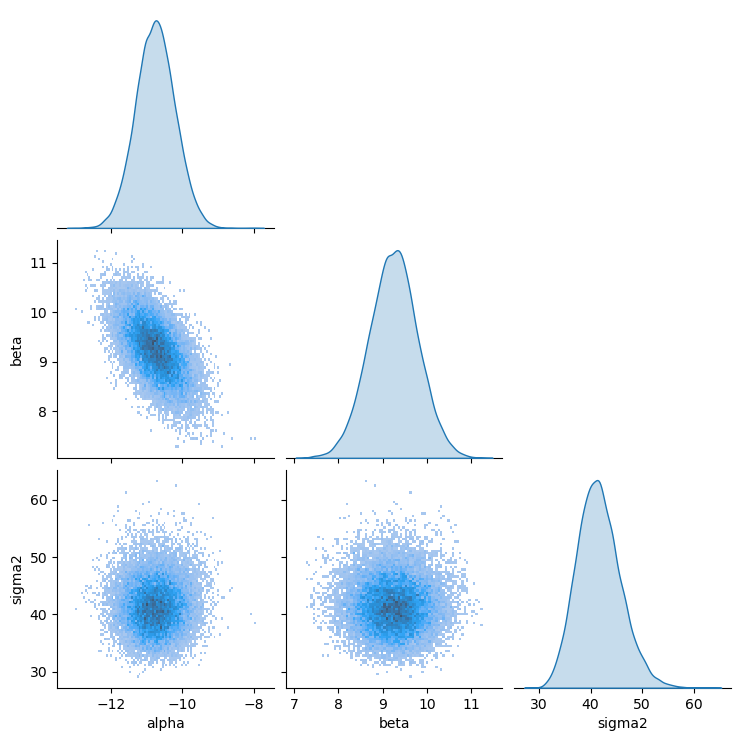

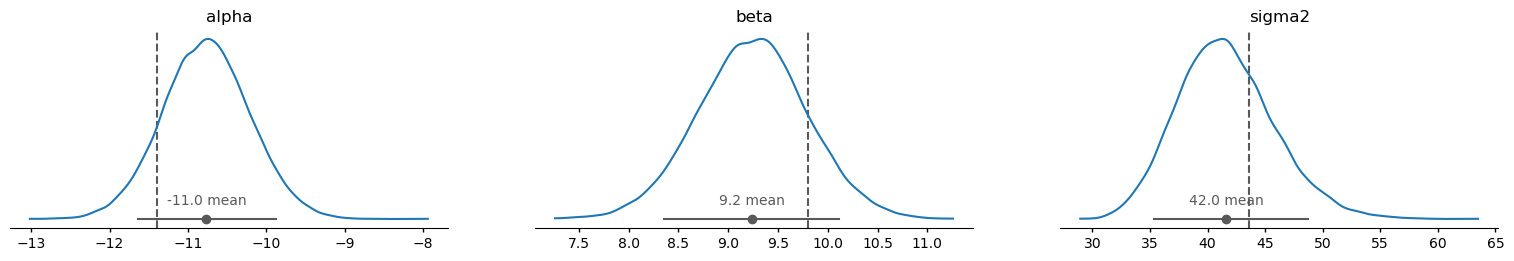

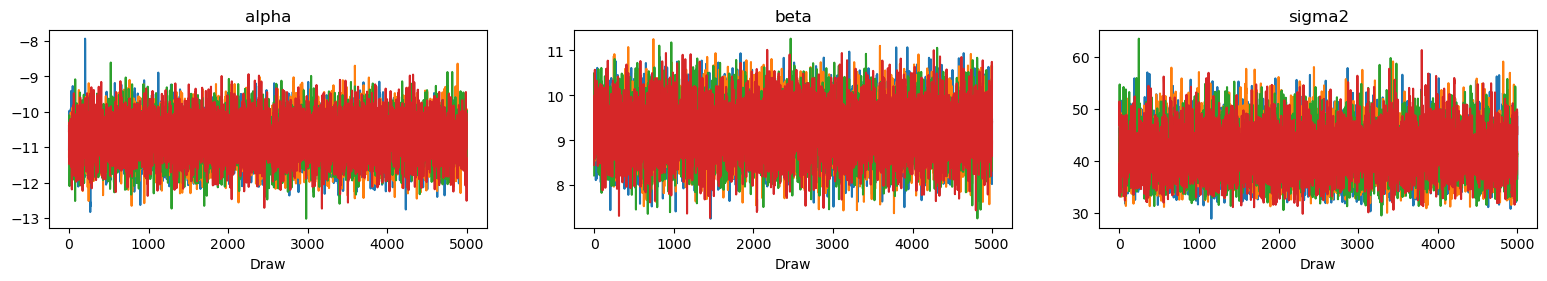

In [56]:
# True model parameters
import json
with open("true_model_params.json") as f:
    true_params=json.load(f)

idata = az.from_cmdstanpy(
    posterior=fit,
    posterior_predictive="y_pp",
    observed_data={"y": data_dict["y"]}
)
idata
sns.pairplot(
    fit.draws_pd(),vars=["alpha","beta","sigma2"],
    kind="hist",diag_kind="kde",corner=True
)
plt.savefig(f"figures/pairplot_N{data_dict['N']}.png")
dist_plt=az.plot_dist(idata,var_names=["alpha","beta","sigma2"])
az.add_lines(dist_plt,values={
    "alpha":true_params["alpha_0"],
    "beta":true_params["beta_0"],
    "sigma2":true_params["sigma_0"]**2,
})
plt.savefig(f"figures/dist_N{data_dict['N']}.png")
az.plot_trace(idata,var_names=["alpha","beta","sigma2"])
plt.savefig(f"figures/trace_N{data_dict['N']}.png")


mean:
	alpha = -10.7637
	beta  =  9.2429
	sigma =  6.4411


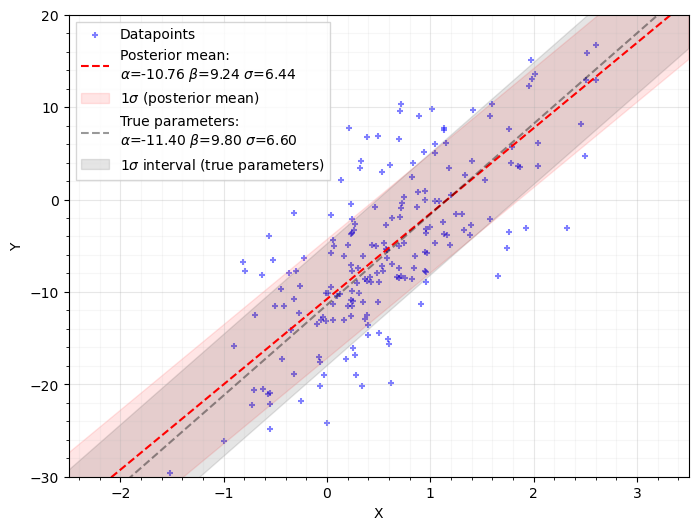

In [57]:
plt.figure(figsize=(8,6))
# N_posterior=len(idata.posterior["alpha"].flatten())
pl_X=np.linspace(-2.5,3.5,2)

alpha_med=np.mean(idata.posterior["alpha"].data.flatten())
beta_med=np.mean(idata.posterior["beta"].data.flatten())
sigma_med=np.mean(idata.posterior["sigma"].data.flatten())
print(f"mean:\n\talpha = {alpha_med: .4f}\n\tbeta  = {beta_med: .4f}\n\tsigma =  {sigma_med:.4f}")

pl_Y_med=alpha_med+pl_X*beta_med
pl_Y_low=pl_Y_med-sigma_med
pl_Y_high=pl_Y_med+sigma_med

plt.scatter(
    data_dict["x"], data_dict["y"],
    marker="+", c="b", s=20, alpha=0.5,
    label="Datapoints"
)

plt.plot(
    pl_X,
    pl_Y_med,
    "r--",
    label=f"Posterior mean:\n$\\alpha$={alpha_med:.2f} $\\beta$={beta_med:.2f} $\\sigma$={sigma_med:.2f}"
)
plt.fill_between(
    pl_X,
    pl_Y_low,
    pl_Y_high,
    color="r",
    alpha=0.1,
    label="1$\\sigma$ (posterior mean)"
)

plt.plot(
    pl_X,
    true_params["alpha_0"]+pl_X*true_params["beta_0"],
    "k--",
    alpha=0.4,
    label=f"True parameters:\n$\\alpha$={true_params['alpha_0']:.2f} $\\beta$={true_params['beta_0']:.2f} $\\sigma$={true_params['sigma_0']:.2f}"
)
plt.fill_between(
    pl_X,
    true_params["alpha_0"]+pl_X*true_params["beta_0"]-true_params["sigma_0"],
    true_params["alpha_0"]+pl_X*true_params["beta_0"]+true_params["sigma_0"],
    color="k",
    alpha=0.1,
    label="1$\\sigma$ interval (true parameters)"
)

plt.minorticks_on()
plt.grid(which="major", alpha=0.3)
plt.grid(which="minor", alpha=0.1)
plt.xlabel("X")
plt.ylabel("Y")
plt.xlim(-2.5,3.5)
plt.ylim(-30,20)
plt.legend(fancybox=False)
plt.savefig(f"figures/meanfit_N{data_dict['N']}.png")
